In [2]:
import pybamm
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from scipy import constants
from pybamm import Scalar

current_directory = os.getcwd()

parameter_values = pybamm.ParameterValues("OKane2022") # 
options = {"thermal": "lumped","lithium plating": "irreversible","SEI":"ec reaction limited", "SEI film resistance":"average", "SEI porosity change": "true","loss of active material": "stress-driven","particle mechanics":"swelling only"}

model = pybamm.lithium_ion.SPM(options=options)

In [3]:
# %load std500cycles_tuneparameters.py
#Parameters tuned for 500 cycles standard
parameter_values.update({"Total heat transfer coefficient [W.m-2.K-1]": 10.0,})
#thermal parameters update
parameter_values.update({"Negative electrode OCP entropic change [V.K-1]": -0.0002,
                         "Positive electrode OCP entropic change [V.K-1]": -0.0004,
                         "Contact resistance [Ohm]": 0.001,
                        })
def ec_diffusivity(T_amb):
    D_sj = 2.5e-22*4*10*3*2 
    EaD = 10000
    arrhenius = np.exp(EaD / pybamm.constants.R *(1/ 298.15 - 1/ T_amb))
    return D_sj * arrhenius


parameter_values.update({"EC diffusivity [m2.s-1]": ec_diffusivity})
#sei parameters update
parameter_values.update({"SEI kinetic rate constant [m.s-1]": 1e-12*0.002*0.5}) 
parameter_values.update({"SEI growth activation energy [J.mol-1]": 48000.0,
                         "SEI partial molar volume [m3.mol-1]": 9.585e-05*0.4,
                         "SEI resistivity [Ohm.m]": 200000.0
                         })  
# LAM parameters update

parameter_values.update({"Positive electrode LAM constant proportional term [s-1]": 0.1*0.5*1.5/3600,
                         "Negative electrode LAM constant proportional term [s-1]": 0.2*0.5*1.5/3600,
                         
                         "Positive electrode LAM constant exponential term": 2.0*1.1,
                         "Negative electrode LAM constant exponential term": 2.0*1.1,
                         
                         })





#Plating paremeters update
parameter_values.update({
                        "Lithium plating kinetic rate constant [m.s-1]": 1e-09*0.001,
                        
                        })


In [4]:
current_directory

'/home/ganmad/batterycode/pybammlocal/PyBaMMlocal/wip'

In [12]:
from itertools import product


temp_list = [10, 25, 40] #25,
crate_list = [0.1, 0.3, 1] #,[0.1,0.3, 1]
soc_list = [10, 60, 100] #,[10, 60, 100] 
dod_list = [50, 70, 90] #60, 70,[50, 70, 90]

all_cases = list(product(temp_list, crate_list, soc_list, dod_list))

df = pd.DataFrame(all_cases,columns = ["Temperature", "C_rate", "SoC", "DoD"])
df.insert(0, "Case", range(1, len(df)+1))
df.to_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv", index=False)

In [13]:
df

,Case,Temperature,C_rate,SoC,DoD
0,1,10,0.1,10,50
1,2,10,0.1,10,70
2,3,10,0.1,10,90
3,4,10,0.1,60,50
4,5,10,0.1,60,70
...,...,...,...,...,...
76,77,40,1.0,60,70
77,78,40,1.0,60,90
78,79,40,1.0,100,50
79,80,40,1.0,100,70


## Case studies for cyclic ageing

Cycling:  34%|███▎      | 3676/10950 [01:54<03:45, 32.21it/s]


Took 42.622 s


Cycling:  25%|██▌       | 2770/10950 [01:26<04:16, 31.86it/s]


Took 33.676 s


Cycling:  22%|██▏       | 2371/10950 [01:16<04:36, 30.97it/s]


...

Took 3.827 s


Cycling:   4%|▎         | 387/10950 [00:10<04:36, 38.19it/s]2026-03-10 14:04:02.006 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Zero negative electrode porosity cut-off' was triggered during 'Rest for 1356 min (60 minute period)'. The returned solution only contains up to step 1 of cycle 390. 
Cycling:   4%|▎         | 389/10950 [00:10<04:44, 37.07it/s]


Took 3.783 s


Cycling:   4%|▎         | 394/10950 [00:10<04:36, 38.16it/s]2026-03-10 14:04:18.781 - [WARNING] callbacks.on_experiment_infeasible_event(254): 

	Experiment is infeasible: 'event: Zero negative electrode porosity cut-off' was triggered during 'Rest for 1332 min (60 minute period)'. The returned solution only contains up to step 1 of cycle 396. 
Cycling:   4%|▎         | 395/10950 [00:10<04:45, 36.95it/s]


Took 3.925 s


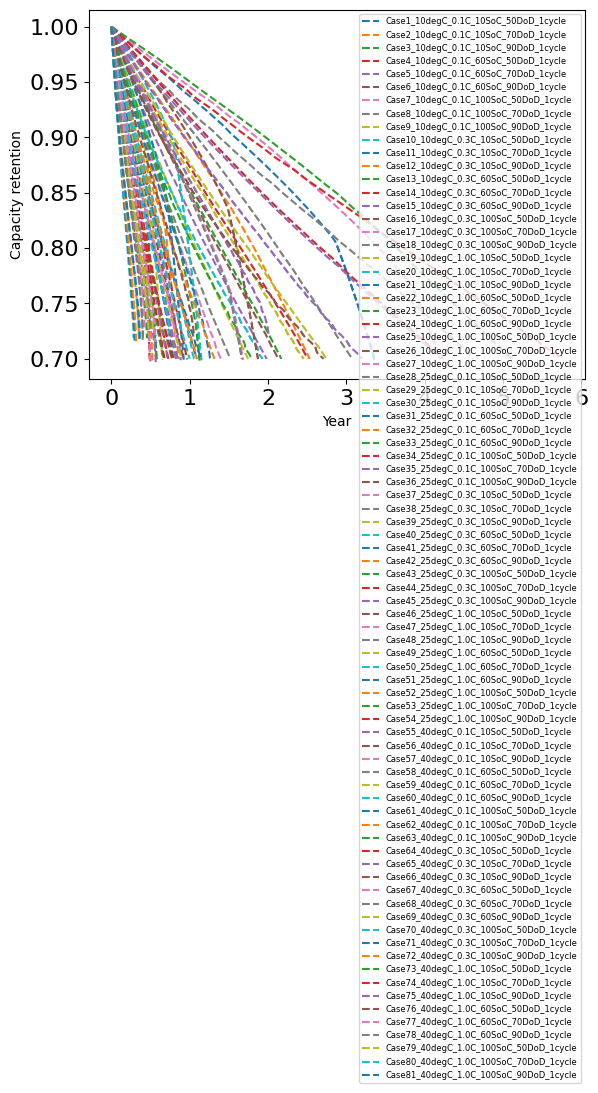

In [ ]:
cycles_per_day = 1
days_per_year = 365 #365
years_for_sim = 10
termination_capacity = 70
time_per_cycle = 24/cycles_per_day #in hours
soc_upper_cutoff = 1
soc_lower_cutoff = 0
max_dod = soc_upper_cutoff - soc_lower_cutoff
crate_ref = 0.1
period_charge_discharge = 5
period_rest = 60
safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 50}) #options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max options={"dt_max": 5}

df_conditions = {}
df_conditions = pd.DataFrame(df_conditions)
simcase_list = []
experiment_list = []
no_steps_list = []
ifcond_cycle_list = []

for n in range(81):
    tempC_case = df["Temperature"][n]
    simcase = df["Case"][n]
    dod_case = df["DoD"][n]*0.01
    soc_case = df["SoC"][n]*0.01
    crate = df["C_rate"][n]
    
    parameter_values.update({"Ambient temperature [K]": 273.15 + tempC_case,
                            "Initial temperature [K]": 273.15 + tempC_case})

    t_soc0 = (1-soc_case)*60/crate_ref #time in minutes
    

    if soc_case == 1:
        exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for 1 seconds")])
        sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0, solver=safe_solver)
        sol0 = sim0.solve()
        model1 = model.set_initial_conditions_from(sol0)
    else:
        exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for {t_soc0} minutes")])
        sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0, solver=safe_solver)
        sol0 = sim0.solve()
        model1 = model.set_initial_conditions_from(sol0)
        

    discharge_time = int(60/crate*dod_case) # in minutes
    charge_time = int(60/crate*dod_case) # in minutes
    rest_time = int(time_per_cycle*60) - discharge_time - charge_time

    discharge_string = f"Discharge at {crate}C for {discharge_time} min or until 2.5V ({period_charge_discharge} minute period)"
    charge_string = f"Charge at {crate}C for {charge_time} min or until 4.2V ({period_charge_discharge} minute period)"
    rest_string = f"Rest for {rest_time} min ({period_rest} minute period)"


    if (soc_case-dod_case) >= soc_lower_cutoff:
        list_of_steps_auto = list([discharge_string, charge_string, rest_string])
        #print(f"C1: for Case{simcase}")
        ifcond_cycle = f"C1: for Case{simcase}"
    elif (soc_case+dod_case)<= soc_upper_cutoff:
        list_of_steps_auto = list([charge_string, discharge_string, rest_string])
        #print(f"C2: for Case{simcase}")
        ifcond_cycle = f"C2: for Case{simcase}"
    elif soc_case ==0.5 and dod_case > soc_case:
        discharge_to_soc_time = int(60/crate*(dod_case-soc_case))
        updated_rest_time = rest_time - discharge_to_soc_time
        discharge_to_soc_string = f"Discharge at {crate}C for {discharge_to_soc_time} minutes ({period_charge_discharge} minute period)"
        updated_rest_string = f"Rest for {updated_rest_time} minutes ({period_rest} minute period)"
        #print(f"C3: for Case{simcase}")
        ifcond_cycle = f"C3: for Case{simcase}"
        
        list_of_steps_auto = list([discharge_string, charge_string, discharge_to_soc_string, updated_rest_string]) # discharge_to_soc_string,
    elif soc_case > 0.5 and dod_case > soc_case:
                
        charge_to_soc_time = int(60/crate*(dod_case- (1-soc_case)))
        updated_rest_time = rest_time - charge_to_soc_time
        charge_to_soc_string = f"Charge at {crate}C for {charge_to_soc_time} minutes ({period_charge_discharge} minute period)"
        updated_rest_string = f"Rest for {updated_rest_time} minutes ({period_rest} minute period)"
        
        list_of_steps_auto = list([charge_string, discharge_string, charge_to_soc_string, updated_rest_string]) # discharge_to_soc_string,
        #print(f"C4: for Case{simcase}")
        ifcond_cycle = f"C4: for Case{simcase}"
        
        
    else:
        print(f"couldn't get the list of steps for Case{simcase}")
        list_of_steps_auto = list([rest_string])
        ifcond_cycle = f"Conditions didn't match for Case{simcase}"
        
    steps_total = len(list_of_steps_auto)
        
    simcase_list.append(f"Case {simcase}: {tempC_case}degC, {soc_case*100}%SoC, {crate}C, {dod_case*100}%DoD, {cycles_per_day}cycles")
    no_steps_list.append(steps_total)
    experiment_list.append(list_of_steps_auto)
    ifcond_cycle_list.append(ifcond_cycle)
    
    exp1 = pybamm.Experiment(list_of_steps_auto*cycles_per_day*days_per_year*years_for_sim, termination=f"{termination_capacity}% capacity")
    sim1 = pybamm.Simulation(model=model1, parameter_values=parameter_values, experiment=exp1, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    
    Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
    cycle1 = sim1.solution.summary_variables["Cycle number"]
    Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

    mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
    mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
    Qlli = sim1.solution.summary_variables['Loss of lithium inventory [%]']
    Qside = sim1.solution.summary_variables["Total capacity lost to side reactions [A.h]"]
    Qsei  = sim1.solution.summary_variables['Loss of capacity to negative SEI [A.h]']
    
    df2 = {}
    df2 = pd.DataFrame(df2)
    df2["Cycle number"] =cycle1
    df2["Capacity Retention"] = Q1/Q1[0]
    df2["LAMpe_per"] =mlam_p
    df2["LAMne_per"] =mlam_n
    df2["Qsei"] = Qsei
    df2["Qpl"] = Qpl
    df2["LLIp"] = Qlli
    df2["Qside"] = Qside
    
    
    df2.to_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")

    plt.plot(cycle1/(cycles_per_day)/days_per_year,Q1/Q1[0],"--", label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    plt.legend(fontsize=6)
    
    
    discharge_time = None
    charge_time = None
    rest_time = None
    discharge_to_soc_time = None
    list_of_steps_auto = None
    updated_rest_time = None
    ifcond_cycle = None
    
    

plt.xlabel("Year")
plt.ylabel("Capacity retention")
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.show()


df_conditions["simcase"] = simcase_list
df_conditions["Experiment"] = experiment_list
df_conditions["n_steps"] = no_steps_list
df_conditions["condition"] = ifcond_cycle_list
df_conditions.to_csv(f"{current_directory}/paperstudies2026/experimentslist2.csv")



In [45]:
soc_case

0.1

In [46]:
simcase

55

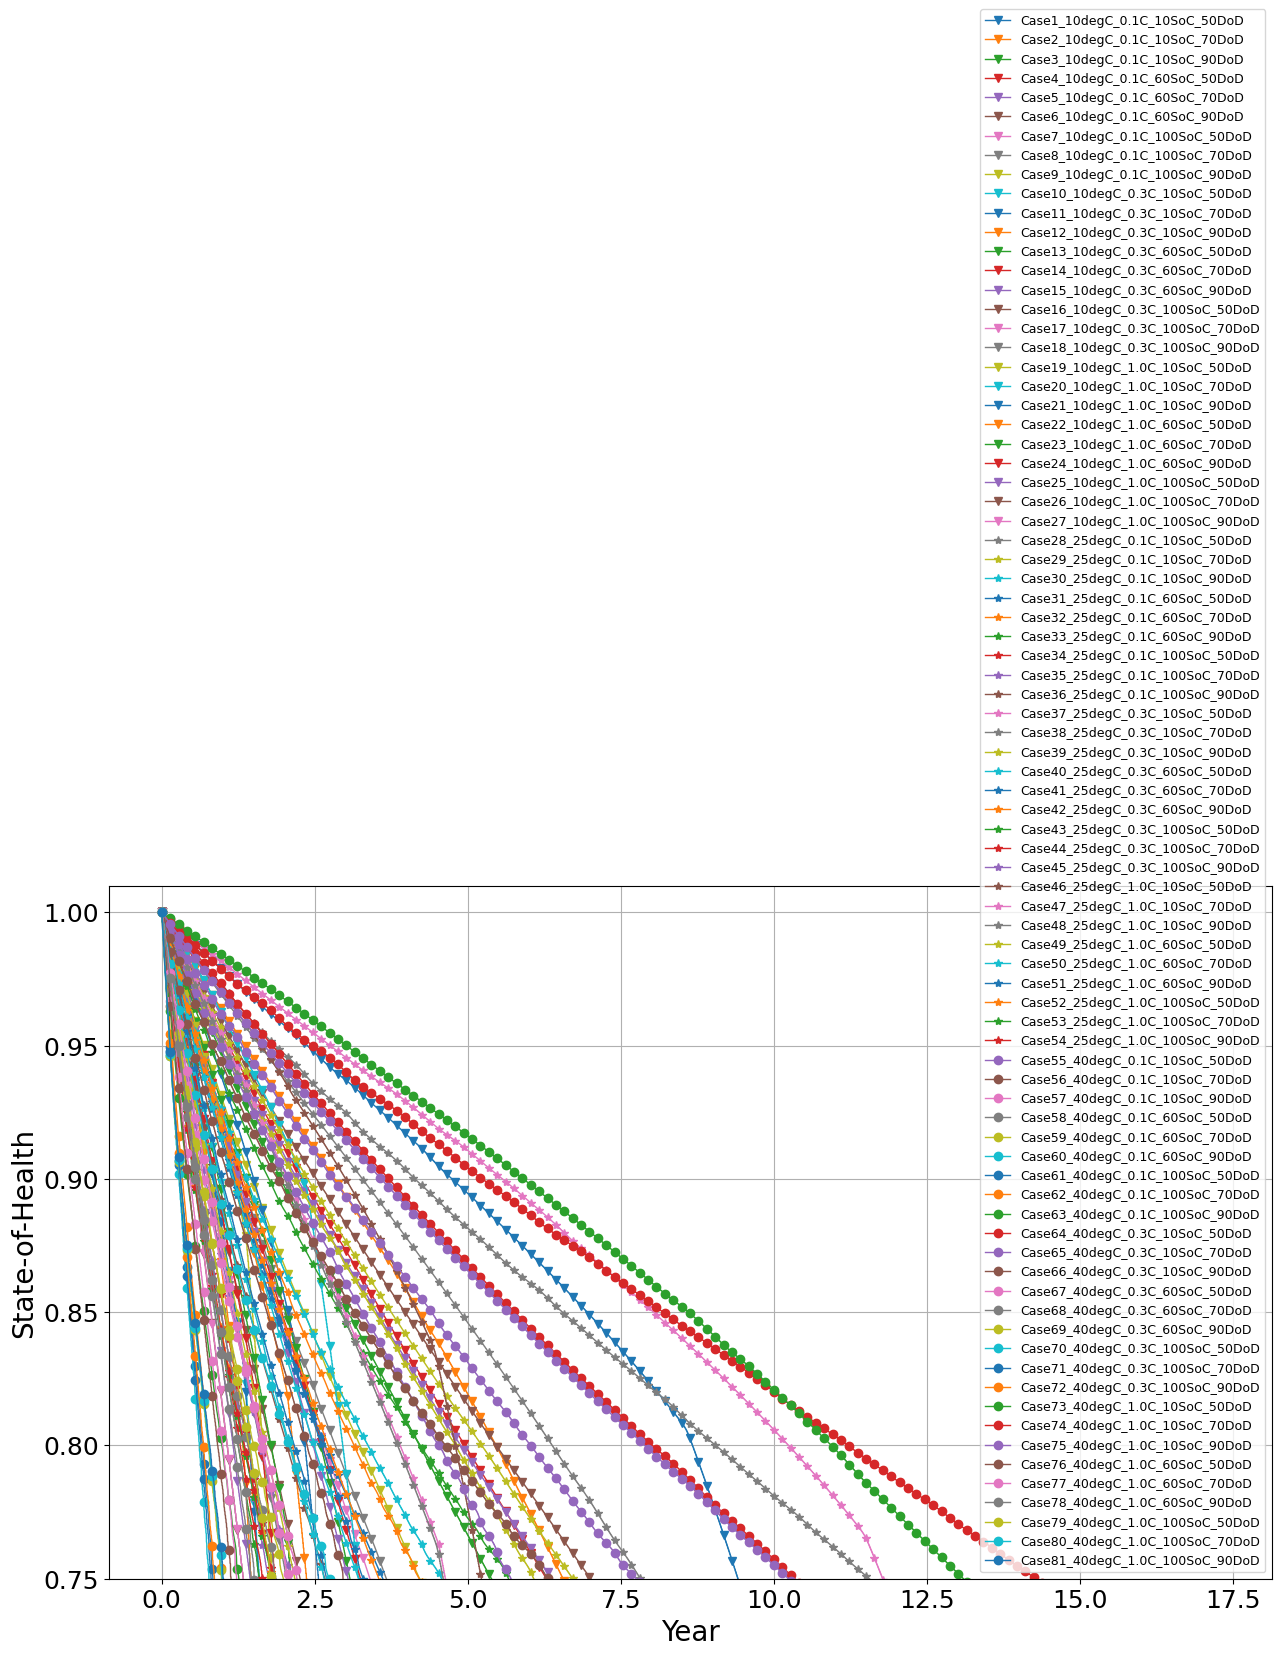

In [112]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
days_per_year = 365
plt.figure(figsize=(15,9))
b =0
for m in range(27):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54) (54, 81):#: #range(5): #(54, 81)[5,11,12,13,15,17,23,27]:#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]
    #b= b+1
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='v', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in range(27,54):   #range(27,54):#: #range(5): #(54, 81)
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='*', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in range(54,81): #range(27,54):#: #range(5): #
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='o', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Year',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
#plt.title('SoH of a NMC/Graphite-Si Lithium-Ion Cell-DFN Model',fontsize=20)
plt.ylim([0.75, 1.01])
#plt.xlim([-50, 1000])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

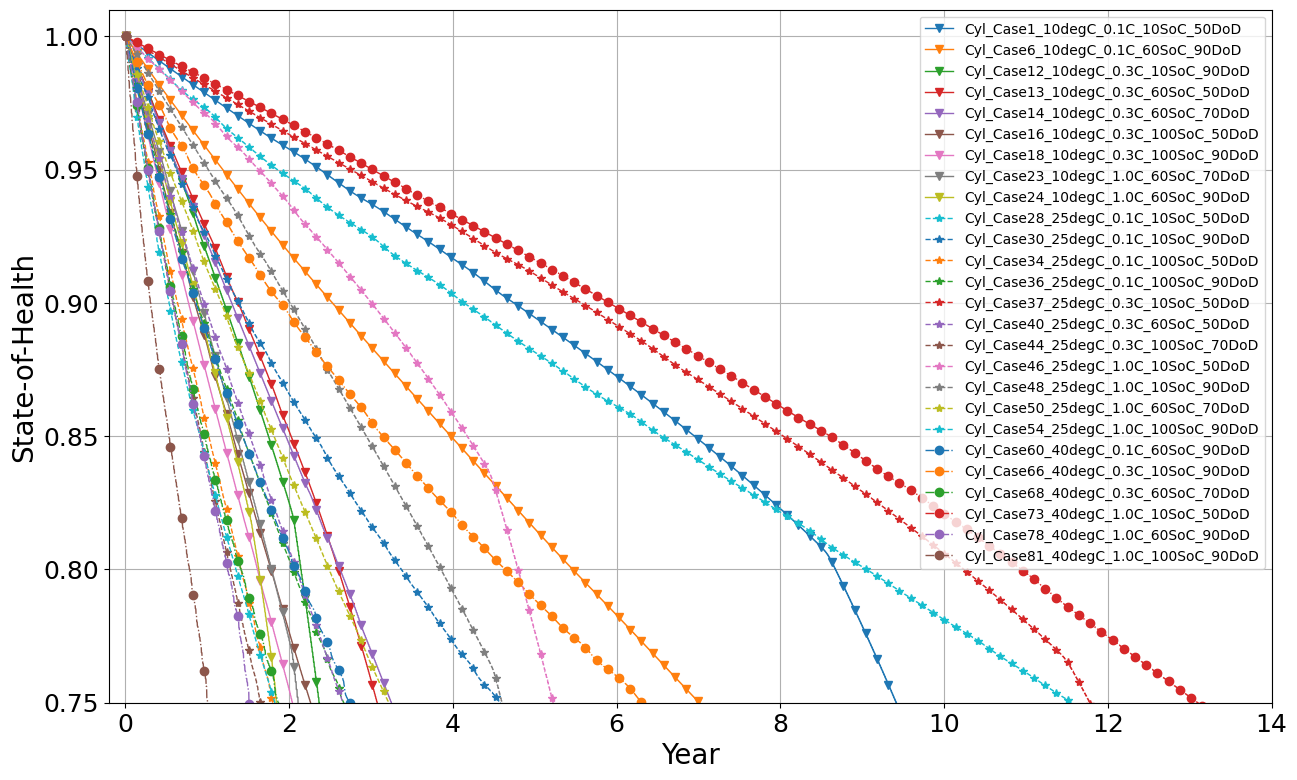

In [82]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
days_per_year = 365
plt.figure(figsize=(15,9))
b =0
for m in [0,5,11,12,13,15,17,22,23]:#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54) (54, 81):#: #range(5): #(54, 81)[5,11,12,13,15,17,23,27],29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]
    #b= b+1
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='v', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in [27,29,33,35,36,39,43,45,47,49,53]:   #range(27,54):#: #range(5): #(54, 81)
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='*', ls='--', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in [59,65,67,72,77,80]: #range(27,54):#: #range(5): #
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='o',ls='-.', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Year',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
#plt.title('SoH of a NMC/Graphite-Si Lithium-Ion Cell-DFN Model',fontsize=20)
plt.ylim([0.75, 1.01])
plt.xlim([-0.2, 14])
plt.legend(fontsize=10)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

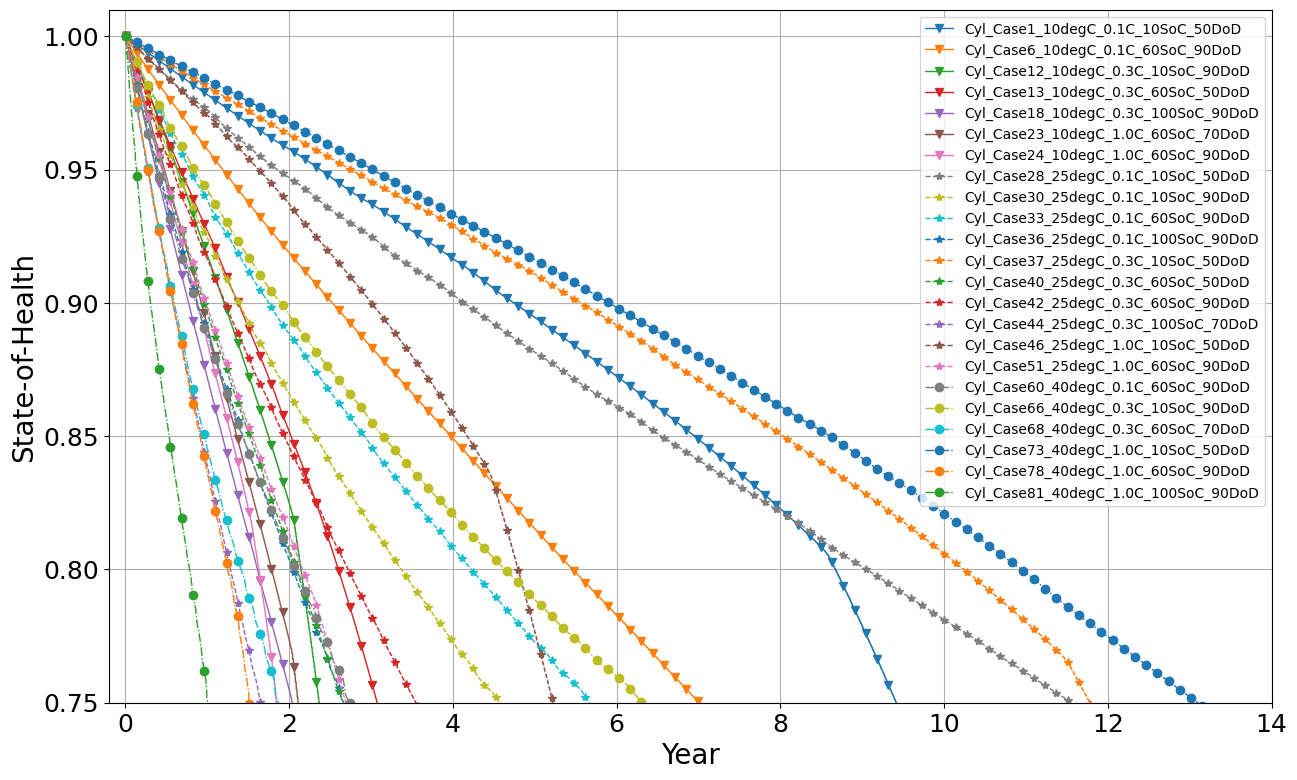

In [108]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
days_per_year = 365
plt.figure(figsize=(15,9))
b =0
for m in [0,5,11,12,17,22,23]:#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54) (54, 81):#: #range(5): #(54, 81)[5,11,12,13,15,17,23,27],29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]
    #b= b+1
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='v', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in [27,29,32, 35,36,39,41, 43,45,50]:   #range(27,54):#: #range(5): #(54, 81)
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='*', ls='--', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in [59,65,67,72,77,80]: #range(27,54):#: #range(5): #
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='o',ls='-.', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Year',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
#plt.title('SoH of a NMC/Graphite-Si Lithium-Ion Cell-DFN Model',fontsize=20)
plt.ylim([0.75, 1.01])
plt.xlim([-0.2, 14])
plt.legend(fontsize=10)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

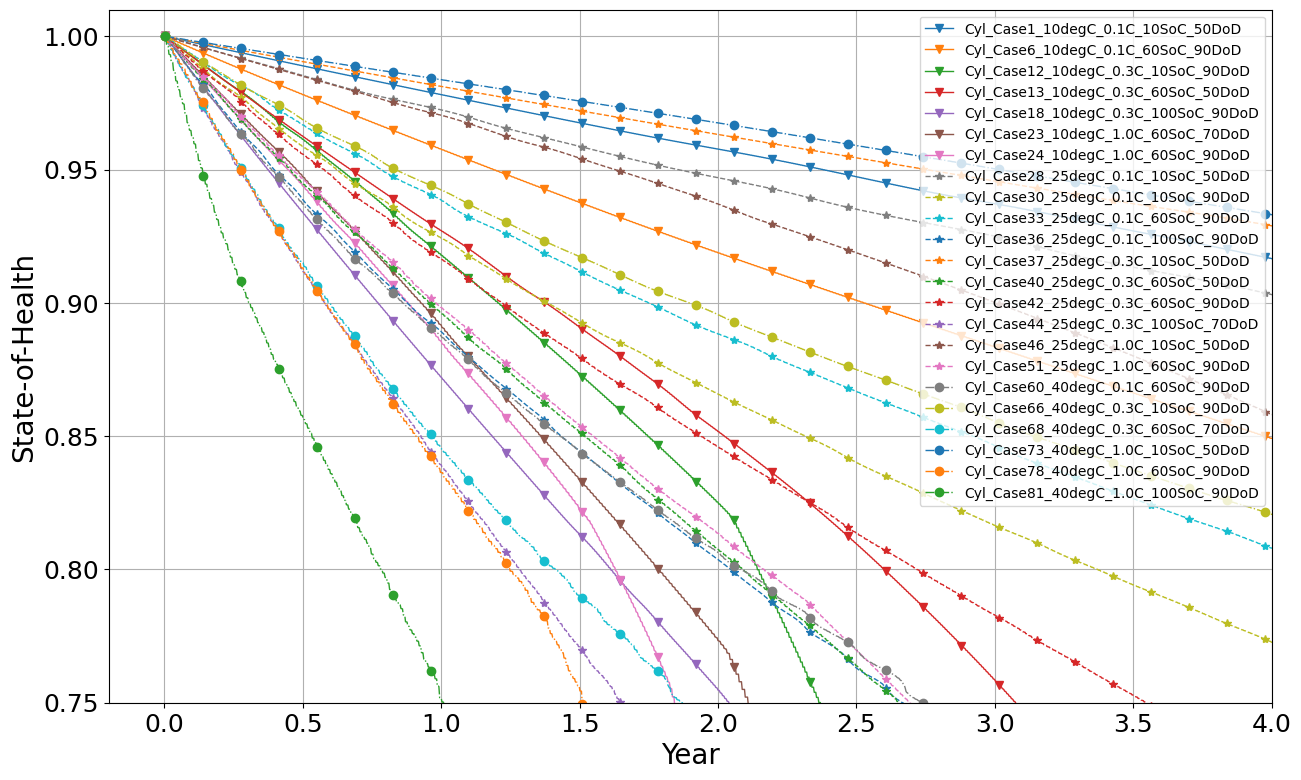

In [104]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
days_per_year = 365
plt.figure(figsize=(15,9))
b =0
for m in [0,5,11,12,17,22,23]:#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54) (54, 81):#: #range(5): #(54, 81)[5,11,12,13,15,17,23,27],29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]
    #b= b+1
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='v', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in [27,29,32, 35,36,39,41, 43,45,50]:   #range(27,54):#: #range(5): #(54, 81)
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='*', ls='--', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in [59,65,67,72,77,80]: #range(27,54):#: #range(5): #
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='o',ls='-.', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Year',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
#plt.title('SoH of a NMC/Graphite-Si Lithium-Ion Cell-DFN Model',fontsize=20)
plt.ylim([0.75, 1.01])
plt.xlim([-0.2, 4])
plt.legend(fontsize=10,loc='upper right')
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()

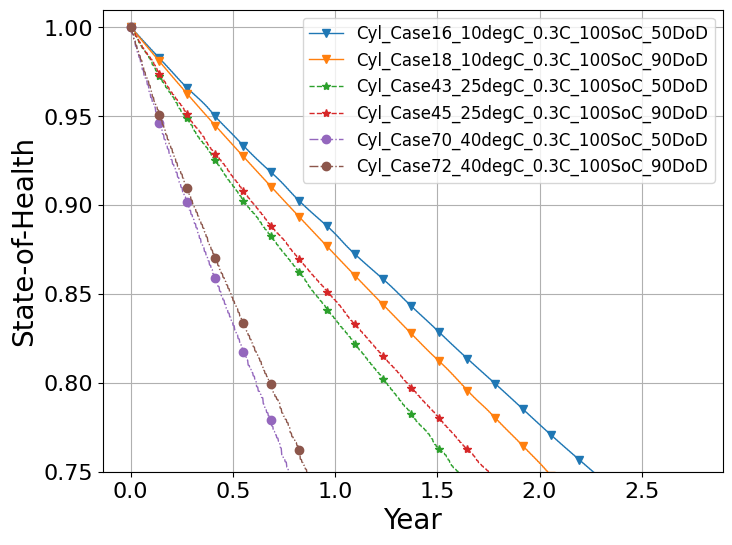

In [153]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
days_per_year = 365
plt.figure(figsize=(8,6))
b=0
for m in [15,17]:#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
    #b= b+1
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/(cycles_per_day)/days_per_year, df4["Capacity Retention"],marker='v', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in [42,44]:   #range(27,54):#: #range(5): #(54, 81)
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/cycles_per_day/days_per_year, df4["Capacity Retention"],marker='*',ls='--', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

for m in [69,71]: #range(27,54):#: #range(5): #
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Cycle number"]/cycles_per_day/days_per_year, df4["Capacity Retention"],marker='o',ls='-.', markevery=50,linewidth=1, label =f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel('Year',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
# plt.title('Combined Ageing',fontsize=20)
plt.ylim([0.75, 1.01])
#plt.xlim([-50, 1000])
plt.legend(fontsize=12)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True)
plt.show()

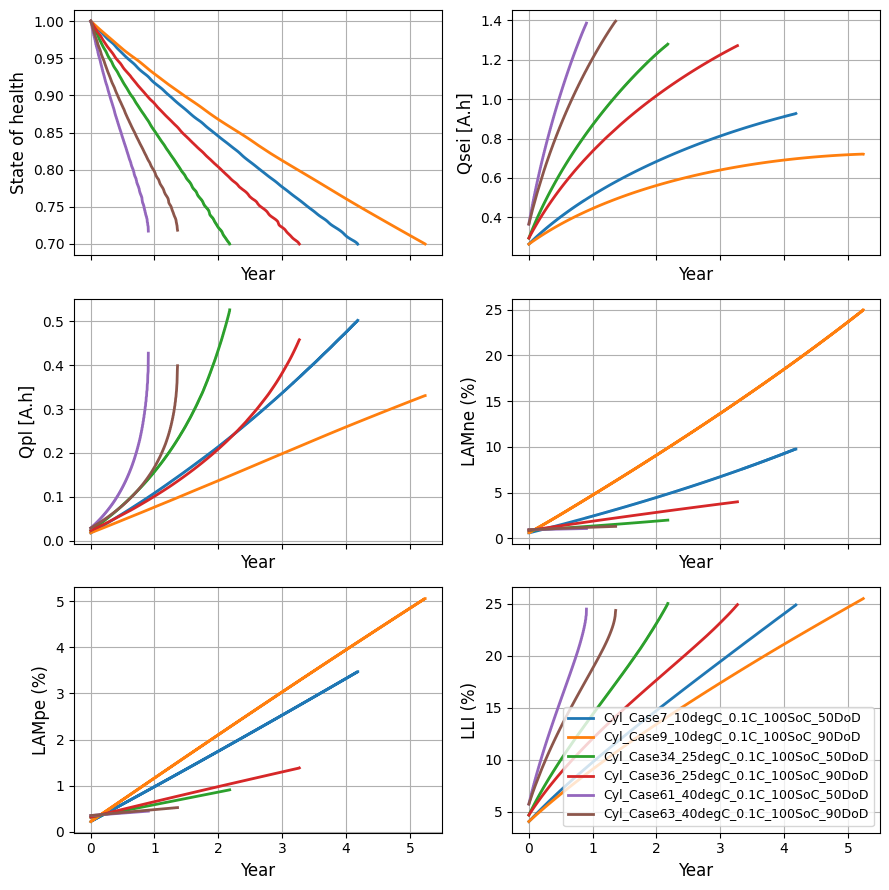

In [140]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
days_per_year =365
b =-9

fig, axes = plt.subplots(3, 2, figsize=(9,9), sharex=True)
axes = axes.flatten()
for m in [15,17,42,44,69,71]:#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
   
    n = m+b
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    
    xcycle = df4["Cycle number"]/cycles_per_day/365
    
    variables = ["Capacity Retention",  "Qsei", "Qpl", "LAMne_per", "LAMpe_per",  "LLIp", ]
    variables2 = ["State of health",  "Qsei [A.h]", "Qpl [A.h]", "LAMne (%)", "LAMpe (%)",  "LLI (%)", ] #"Qside",
    
    for i, var in enumerate(variables):

        axes[i].plot(xcycle, df4[var], label = f"Cyl_Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD", linewidth=2)
        #axes[i].set_title(var)
        
            # X-axis label
        axes[i].set_ylabel(f"{variables2[i]}",fontsize=12)         # Y-axis label
        
        axes[i].set_xlabel("Year", fontsize=12) 
        # axes[i].set_ylim([.75, 1.01]) 
        axes[i].grid(True)
    axes[i].legend(fontsize=9)
#plt.xlabel("Cycle number") 

plt.tight_layout()
plt.show()


In [ ]:
#sim1.plot()
#sol1.save("DFN_300cyl_fail-sol.pkl")

In [ ]:
# safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 5}) #mode="safe", ,  dt_max= dt_max, return_solution_if_failed_early=True, dt_max= 5.0,

# parameter_values.update({"Ambient temperature [K]": 298.15,
#                         "Initial temperature [K]": 298.15 })

# sim1 = pybamm.Simulation(model=model, parameter_values=parameter_values, experiment=experiment0, solver=safe_solver) #
# sol1 = sim1.solve(showprogress=True)
# print("Took", sol1.solve_time)







Cycling:  46%|████▌     | 460/1000 [14:23<16:53,  1.88s/it]

Took 13 minutes, 19 seconds


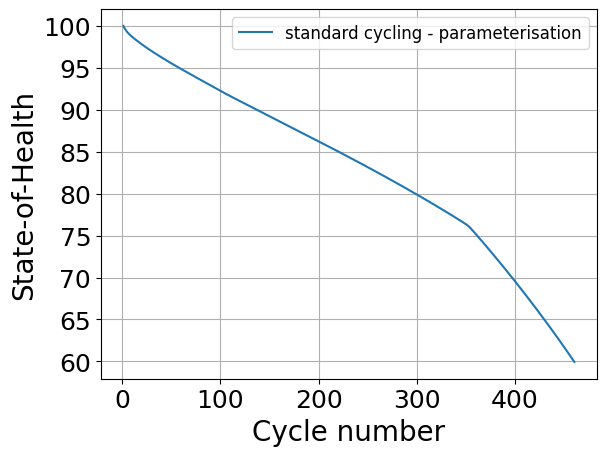

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
cycle1 = sim1.solution.summary_variables["Cycle number"]
plt.plot(cycle1, 100*(Q1/Q1[0]), label = "standard cycling - parameterisation")
plt.legend(fontsize=12)

plt.xlabel('Cycle number',fontsize=20)
plt.ylabel('State-of-Health',fontsize=20)
# plt.title('SoH of a Lithium-Ion Cell-DFN Model',fontsize=20)
#plt.ylim([75, 101])
# #plt.xlim([-50, 500])
# plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
# plt.show()

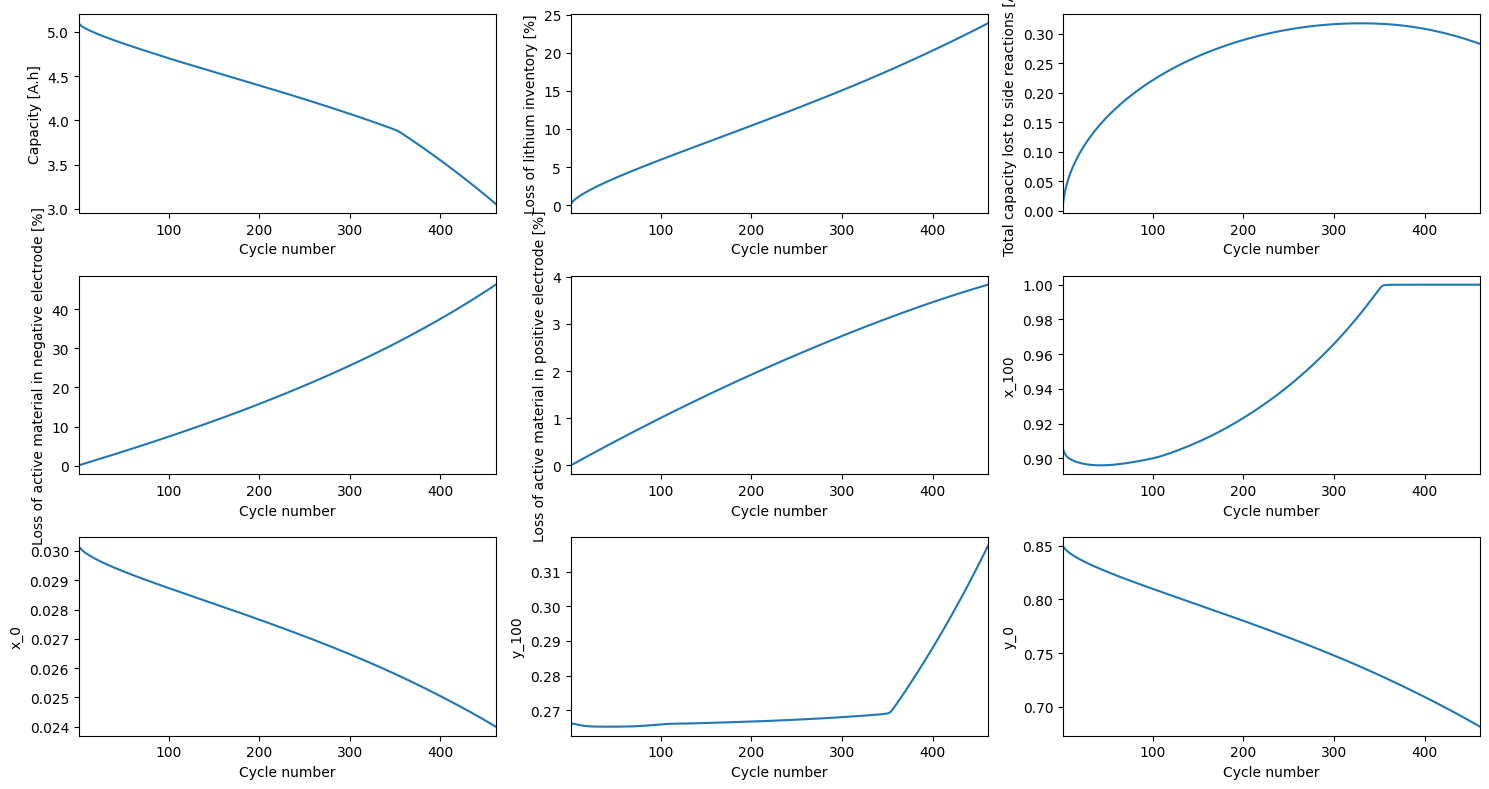

array([[<Axes: xlabel='Cycle number', ylabel='Capacity [A.h]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of lithium inventory [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Total capacity lost to side reactions [A.h]'>],
       [<Axes: xlabel='Cycle number', ylabel='Loss of active material in negative electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='Loss of active material in positive electrode [%]'>,
        <Axes: xlabel='Cycle number', ylabel='x_100'>],
       [<Axes: xlabel='Cycle number', ylabel='x_0'>,
        <Axes: xlabel='Cycle number', ylabel='y_100'>,
        <Axes: xlabel='Cycle number', ylabel='y_0'>]], dtype=object)

In [ ]:
pybamm.plot_summary_variables(sim1.solution)

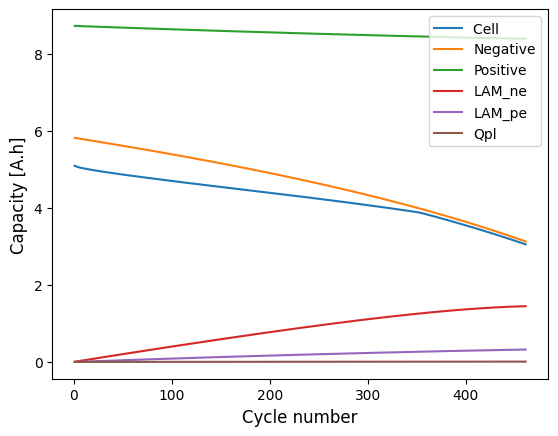

In [ ]:
Q1 = sim1.solution.summary_variables["Capacity [A.h]"]
Qnes = sim1.solution.summary_variables["Negative electrode capacity [A.h]"]
Qpes = sim1.solution.summary_variables["Positive electrode capacity [A.h]"]
Qpl=  sim1.solution.summary_variables["Loss of capacity to negative lithium plating [A.h]"]

mlam_n = sim1.solution.summary_variables['Loss of active material in negative electrode [%]']
mlam_p = sim1.solution.summary_variables['Loss of active material in positive electrode [%]']
cycle1s = sim1.solution.summary_variables["Cycle number"]

r1 = [a*b/100 for a, b in zip(mlam_n,Qnes)]
r2 = [a*b/100 for a, b in zip(mlam_p,Qpes)]
plt.plot(cycle1s, Q1, label="Cell ")
plt.plot(cycle1s, Qnes, label="Negative")
plt.plot(cycle1s, Qpes, label="Positive")
plt.plot(cycle1s, r1, label="LAM_ne")
plt.plot(cycle1s, r2, label="LAM_pe")
plt.plot(cycle1s, Qpl, label="Qpl")

plt.xlabel('Cycle number',fontsize=12)
plt.ylabel('Capacity [A.h]',fontsize=12)
plt.legend()


## First cycle for each case

Cycling: 100%|██████████| 3/3 [00:00<00:00,  8.73it/s]


Took 35.371 ms


Cycling: 100%|██████████| 3/3 [00:00<00:00,  8.55it/s]


Took 39.287 ms


Cycling: 100%|██████████| 3/3 [00:00<00:00,  9.30it/s]


...

Took 29.382 ms


Cycling: 100%|██████████| 3/3 [00:00<00:00,  8.73it/s]


Took 32.788 ms


Cycling: 100%|██████████| 3/3 [00:00<00:00,  9.55it/s]


Took 30.735 ms


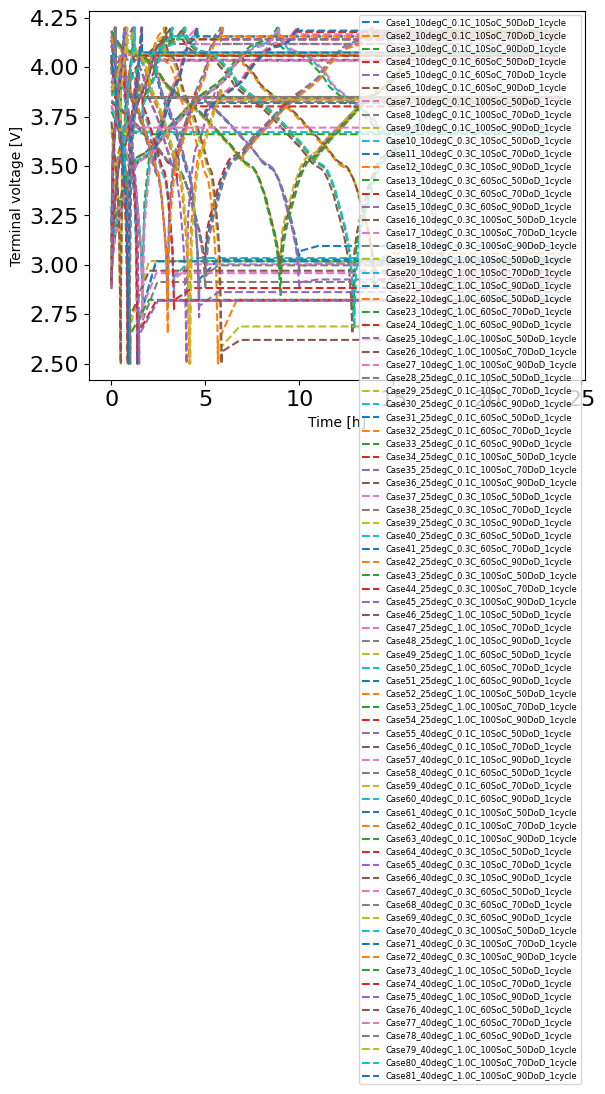

In [ ]:
## First cycle for each case
cycles_per_day = 1
days_per_year = 1 #365
years_for_sim = 1
termination_capacity = 70
time_per_cycle = 24/cycles_per_day #in hours
soc_upper_cutoff = 1
soc_lower_cutoff = 0
max_dod = soc_upper_cutoff - soc_lower_cutoff
crate_ref = 0.1
period_charge_discharge = 5
period_rest = 60
safe_solver = pybamm.IDAKLUSolver(options={"dt_max": 50}) #options={"dt_max": 10}) #mode="safe", ,  dt_max= dt_max options={"dt_max": 5}

df_conditions = {}
df_conditions = pd.DataFrame(df_conditions)
simcase_list = []
experiment_list = []
no_steps_list = []
ifcond_cycle_list = []

for n in range(81):
    tempC_case = df["Temperature"][n]
    simcase = df["Case"][n]
    dod_case = df["DoD"][n]*0.01
    soc_case = df["SoC"][n]*0.01
    crate = df["C_rate"][n]
    
    parameter_values.update({"Ambient temperature [K]": 273.15 + tempC_case,
                            "Initial temperature [K]": 273.15 + tempC_case})

    t_soc0 = (1-soc_case)*60/crate_ref #time in minutes
    # exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for {t_soc0} minutes")])
    # sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0)
    # sol0 = sim0.solve()

    if soc_case == 1:
        exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for 1 seconds")])
        sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0, solver=safe_solver)
        sol0 = sim0.solve()
        model1 = model.set_initial_conditions_from(sol0)
        
    else:
        exp0 = pybamm.Experiment([(f"Charge at {crate_ref}C until 4.2V", "Hold at 4.2V until 50 mA", f"Discharge at {crate_ref}C for {t_soc0} minutes")])
        sim0 = pybamm.Simulation(model=model, parameter_values= parameter_values, experiment=exp0, solver=safe_solver)
        sol0 = sim0.solve()
        model1 = model.set_initial_conditions_from(sol0)
        

    discharge_time = int(60/crate*dod_case) # in minutes
    charge_time = int(60/crate*dod_case) # in minutes
    rest_time = int(time_per_cycle*60) - discharge_time - charge_time

    discharge_string = f"Discharge at {crate}C for {discharge_time} min or until 2.5V ({period_charge_discharge} minute period)"
    charge_string = f"Charge at {crate}C for {charge_time} min or until 4.2V ({period_charge_discharge} minute period)"
    rest_string = f"Rest for {rest_time} min ({period_rest} minute period)"


    if (soc_case-dod_case) >= soc_lower_cutoff:
        list_of_steps_auto = list([discharge_string, charge_string, rest_string])
        #print(f"C1: for Case{simcase}")
        ifcond_cycle = f"C1: for Case{simcase}"
    elif (soc_case+dod_case)<= soc_upper_cutoff:
        list_of_steps_auto = list([charge_string, discharge_string, rest_string])
        #print(f"C2: for Case{simcase}")
        ifcond_cycle = f"C2: for Case{simcase}"
    elif soc_case ==0.5 and dod_case > soc_case:
        discharge_to_soc_time = int(60/crate*(dod_case-soc_case))
        updated_rest_time = rest_time - discharge_to_soc_time
        discharge_to_soc_string = f"Discharge at {crate}C for {discharge_to_soc_time} min ({period_charge_discharge} minute period)"
        updated_rest_string = f"Rest for {updated_rest_time} min ({period_rest} minute period)"
        #print(f"C3: for Case{simcase}")
        ifcond_cycle = f"C3: for Case{simcase}"
        
        list_of_steps_auto = list([discharge_string, charge_string, discharge_to_soc_string, updated_rest_string]) # discharge_to_soc_string,
    elif soc_case > 0.5 and dod_case > soc_case:
                
        charge_to_soc_time = int(60/crate*(dod_case- (1-soc_case)))
        updated_rest_time = rest_time - charge_to_soc_time
        charge_to_soc_string = f"Charge at {crate}C for {charge_to_soc_time} min ({period_charge_discharge} minute period)"
        updated_rest_string = f"Rest for {updated_rest_time} minutes ({period_rest} minute period)"
        
        list_of_steps_auto = list([charge_string, discharge_string, charge_to_soc_string, updated_rest_string]) # discharge_to_soc_string,
        #print(f"C4: for Case{simcase}")
        ifcond_cycle = f"C4: for Case{simcase}"
        
        
    else:
        print(f"couldn't get the list of steps for Case{simcase}")
        list_of_steps_auto = list([rest_string])
        ifcond_cycle = f"Condiitons didn't match for Case{simcase}"
        
    steps_total = len(list_of_steps_auto)
        
    simcase_list.append(f"Case {simcase}: {tempC_case}degC, {soc_case*100}%SoC, {crate}C, {dod_case*100}%DoD, {cycles_per_day}cycles")
    no_steps_list.append(steps_total)
    experiment_list.append(list_of_steps_auto)
    ifcond_cycle_list.append(ifcond_cycle)
    
    exp1 = pybamm.Experiment(list_of_steps_auto*cycles_per_day*days_per_year*years_for_sim, termination=f"{termination_capacity}% capacity")
    sim1 = pybamm.Simulation(model=model1, parameter_values=parameter_values, experiment=exp1, solver=safe_solver)
    sol1 = sim1.solve(showprogress=True, ) #save_at_cycles=50
    print("Took", sol1.solve_time)
    
        
    t1 = sim1.solution["Time [h]"].entries
    Vc1 = sim1.solution["Terminal voltage [V]"].entries
    Temp1 = sim1.solution["X-averaged cell temperature [K]"].entries

    plt.plot(t1, Vc1, "--", label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    #plt.plot(t1, Temp1, "--", label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD_{cycles_per_day}cycle")
    plt.legend(fontsize=6)
    df3 = {}
    df3 = pd.DataFrame(df3)
    df3["Time [h]"] =t1
    df3["Terminal voltage [V]"] = Vc1
    df3["X-averaged cell temperature [K]"] = Temp1
    df3.to_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    
    discharge_time = None
    charge_time = None
    rest_time = None
    discharge_to_soc_time = None
    list_of_steps_auto = None
    updated_rest_time = None
    ifcond_cycle = None
    
    
plt.xlabel("Time [h]")
plt.ylabel("Terminal voltage [V]")
plt.xticks(fontsize =16)
plt.yticks(fontsize = 16)
plt.show()

# df_conditions["simcase"] = simcase_list
# df_conditions["Experiment"] = experiment_list
# df_conditions["n_steps"] = no_steps_list
# df_conditions["condition"] = ifcond_cycle_list
# df_conditions.to_csv(f"{current_directory}/paperstudies2026/experimentslist_81cases.csv")



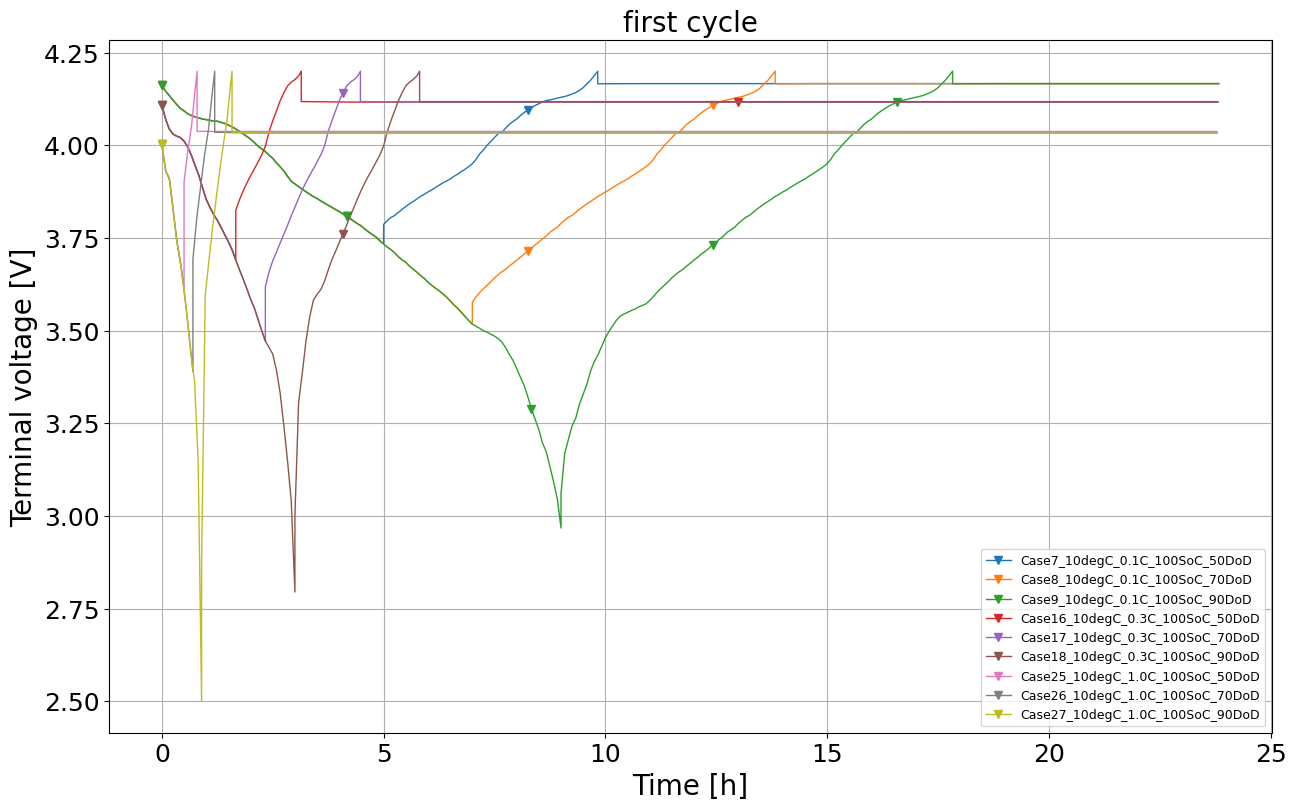

In [52]:
df3 = pd.read_csv(f"{current_directory}/paperstudies2026/Cases_for_ageing.csv")
cycles_per_day =1
plt.figure(figsize=(15,9))
b =0
for m in [6,7,8,15,16,17,24,25,26]: #range(15,18):#,29,31,33,35,37,39,43,45,47,49,51,53,59,65,67,69,71,77,81]: #range(27,54):#: #range(5): #
    #b= b+1
    n = m
    tempC_case = df3["Temperature"][n]
    simcase = df3["Case"][n]
    dod_case = df3["DoD"][n]*0.01
    soc_case = df3["SoC"][n]*0.01
    crate = df3["C_rate"][n]
    df4 = pd.read_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
    plt.plot(df4["Time [h]"], df4["Terminal voltage [V]"],marker='v', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

# for m in range(27,54):   #range(27,54):#: #range(5): #(54, 81)
#     n = m
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Time [h]"], df4["Terminal voltage [V]"],marker='*', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

# for m in range(54,81): #range(27,54):#: #range(5): #
#     n = m
#     tempC_case = df3["Temperature"][n]
#     simcase = df3["Case"][n]
#     dod_case = df3["DoD"][n]*0.01
#     soc_case = df3["SoC"][n]*0.01
#     crate = df3["C_rate"][n]
#     df4 = pd.read_csv(f"{current_directory}/paperstudies2026/firstdaycycle/firstday_Case{simcase}_{tempC_case}degC_{crate}C_{soc_case*100}SoC_{dod_case*100}DoD_{cycles_per_day}cycle.csv")
#     plt.plot(df4["Time [h]"], df4["Terminal voltage [V]"],marker='o', markevery=50,linewidth=1, label =f"Case{simcase}_{tempC_case}degC_{crate}C_{int(soc_case*100)}SoC_{int(dod_case*100)}DoD")

plt.xlabel("Time [h]",fontsize=20)
plt.ylabel("Terminal voltage [V]",fontsize=20)
plt.title('first cycle',fontsize=20)
#plt.ylim([70, 102])
#plt.xlim([-50, 1000])
plt.legend(fontsize=9)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.grid(True)
plt.show()